In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import re
from scipy.stats import percentileofscore

# Generate dataframe of simulated maps' information

## Create primary dataframe with district boundaries, compactness scores, and populations

In [2]:
#print all csv files from the allocation_by_district folder
#note: not in order!
seeds_by_district_csv_files=glob.glob('./allocation_by_district/*.csv')
# seeds_by_district_csv_files

#alt method for printing all the files...
# for files in glob.glob("./allocation_by_district/*.csv"):
#     print(files) 

#this will get an unsorted list of seeds for all files in ./allocation_by_district folder
district_seeds_list=[]
for fname in seeds_by_district_csv_files:
    res = re.findall("seed_(\d+)_by_district.csv", fname)
    if not res: continue
    district_seeds_list.append(res[0]) # You can append the result to a list

In [3]:
district_seeds_list_sorted=sorted(district_seeds_list)

In [4]:
# path is a string for the path of the folder we want to check
# path = os.getcwd() + '/allocation_by_county'
path = os.getcwd() + '/allocation_by_district'

#list of all filenames in the path which end in .csv
csv_files = glob.glob(os.path.join(path, "*.csv")) 
num_files = len(csv_files) #count of all files

# file_name = './allocation_by_county/seed_{}_by_county.csv'
file_name = './allocation_by_district/seed_{}_by_district.csv'
df_list = []

# This previously worked when all seeds were saved regardless of criteria being met
# for i in range(num_files):
#    iter_number=str(i).rjust(3,'0')
#    df_list.append(pd.read_csv(file_name.format(iter_number)))

for seed in district_seeds_list_sorted:
    df_list.append(pd.read_csv(file_name.format(seed)))


In [5]:
# df=pd.read_csv('./allocation_by_district/seed_005_by_district.csv')
# df.head()

In [6]:
full_nestedlist=[]
for j in range(num_files):
    temp_df = df_list[j]
    list_for_j=[district_seeds_list_sorted[j] 
                # ,temp_df.loc[0,'Reock']
                # ,temp_df.loc[1,'Reock']
                # ,temp_df.loc[2,'Reock']
                # ,temp_df.loc[3,'Reock']
                ,temp_df['Reock'].min()
                # ,temp_df['Reock'].max()
                ,temp_df['Reock'].mean()
                # ,temp_df.loc[0,'PolsbyPopper']
                # ,temp_df.loc[1,'PolsbyPopper']
                # ,temp_df.loc[2,'PolsbyPopper']
                # ,temp_df.loc[3,'PolsbyPopper']
                ,temp_df['PolsbyPopper'].min()
                # ,temp_df['PolsbyPopper'].max()
                ,temp_df['PolsbyPopper'].mean()
                ,temp_df.loc[0,'geometry']
                ,temp_df.loc[1,'geometry']
                ,temp_df.loc[2,'geometry']
                ,temp_df.loc[3,'geometry']
                ,temp_df.loc[0,'population']
                ,temp_df.loc[1,'population']
                ,temp_df.loc[2,'population']
                ,temp_df.loc[3,'population']
                ,temp_df['population'].min()
                ,temp_df['population'].max()
                ]
    full_nestedlist.append(list_for_j)

# full_nestedlist

In [7]:
column_dict=[
    'seed'
    # ,'Reock_d1'
    # ,'Reock_d2'
    # ,'Reock_d3'
    # ,'Reock_d4'
    ,'Reock_min'
    # ,'Reock_max'
    ,'Reock_mean'
    # ,'PP_d1'
    # ,'PP_d2'
    # ,'PP_d3'
    # ,'PP_d4'
    ,'PP_min'
    # ,'PP_max'
    ,'PP_mean'
    ,'dist1_gpd'
    ,'dist2_gpd'
    ,'dist3_gpd'
    ,'dist4_gpd'
    ,'dist1_pop'
    ,'dist2_pop'
    ,'dist3_pop'
    ,'dist4_pop'
    ,'min_pop'
    ,'max_pop']

In [8]:
all_maps_df = pd.DataFrame(full_nestedlist,columns=column_dict)
all_maps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   seed        273 non-null    object 
 1   Reock_min   273 non-null    float64
 2   Reock_mean  273 non-null    float64
 3   PP_min      273 non-null    float64
 4   PP_mean     273 non-null    float64
 5   dist1_gpd   273 non-null    object 
 6   dist2_gpd   273 non-null    object 
 7   dist3_gpd   273 non-null    object 
 8   dist4_gpd   273 non-null    object 
 9   dist1_pop   273 non-null    int64  
 10  dist2_pop   273 non-null    int64  
 11  dist3_pop   273 non-null    int64  
 12  dist4_pop   273 non-null    int64  
 13  min_pop     273 non-null    int64  
 14  max_pop     273 non-null    int64  
dtypes: float64(4), int64(6), object(5)
memory usage: 32.1+ KB


In [9]:
duplicates=all_maps_df[all_maps_df.duplicated(subset=['Reock_min', 'Reock_mean', 'min_pop', 'max_pop'], keep=False)]
duplicates.sort_values(by=['Reock_min']).head()

,seed,Reock_min,Reock_mean,PP_min,PP_mean,dist1_gpd,dist2_gpd,dist3_gpd,dist4_gpd,dist1_pop,dist2_pop,dist3_pop,dist4_pop,min_pop,max_pop
114,127,0.322161,0.415539,0.296865,0.342957,"POLYGON ((558373.895623059 4605901.485357738, ...","POLYGON ((420252.0937440044 4712961.129324797,...",POLYGON ((491768.13570150826 4518326.457960803...,"POLYGON ((327366.1385466402 4493729.313993027,...",803655,791149,793091,802474,791149,803655
43,047,0.322161,0.415541,0.297266,0.364589,"POLYGON ((558581.0347951901 4595591.165554848,...","POLYGON ((420252.0937440044 4712961.129324797,...",POLYGON ((491768.13570150826 4518326.457960803...,"POLYGON ((327366.1385466402 4493729.313993027,...",803812,791149,792934,802474,791149,803812
260,286,0.322161,0.415541,0.297266,0.364589,"POLYGON ((327366.1385466402 4493729.313993027,...","POLYGON ((420252.0937440044 4712961.129324797,...","POLYGON ((558581.0347951901 4595591.165554848,...",POLYGON ((491768.13570150826 4518326.457960803...,802474,791149,803812,792934,791149,803812
52,057,0.322161,0.415539,0.296865,0.342957,"POLYGON ((558373.895623059 4605901.485357738, ...","POLYGON ((420252.0937440044 4712961.129324797,...",POLYGON ((491768.13570150826 4518326.457960803...,"POLYGON ((327366.1385466402 4493729.313993027,...",803655,791149,793091,802474,791149,803655
89,100,0.333025,0.428417,0.252851,0.366773,"POLYGON ((452965.6966743361 4501971.787843896,...","POLYGON ((327366.1385466402 4493729.313993027,...","POLYGON ((325806.6758530381 4617350.978689799,...",POLYGON ((519337.18424878584 4654016.738651686...,796929,804149,791221,798070,791221,804149


In [10]:
all_maps_sans_duplicates=all_maps_df.drop_duplicates(subset=['Reock_min', 'Reock_mean', 'min_pop', 'max_pop'], keep='first')
len(all_maps_sans_duplicates)

250

In [11]:
#Export list of seeds to use in other notebooks
all_maps_sans_duplicates['seed'].to_csv('./data/unique_district_seeds.csv', index=False, header=True)

## Create compactness dataframe

In [12]:
column_dict_compactness_analysis=[
    'seed',
    'Reock_min',
    # 'Reock_max',
    'Reock_mean',
    'PP_min',
    # 'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [13]:
compactness_analysis_df = all_maps_sans_duplicates[column_dict_compactness_analysis]
compactness_analysis_df

#show all rows instead of first 5/last 5
# pd.set_option('display.max_rows', None)
# compactness_analysis_df

#reset max_rows:
# pd.reset_option(“max_rows”)

,seed,Reock_min,Reock_mean,PP_min,PP_mean,min_pop,max_pop
0,000,0.332951,0.367877,0.235157,0.302992,790938,804784
1,001,0.448682,0.508731,0.338438,0.435282,791513,802747
2,003,0.428981,0.490348,0.294441,0.339815,791071,804852
3,004,0.342567,0.388122,0.288226,0.358882,795671,800138
4,005,0.460231,0.512357,0.411954,0.454914,795792,798933
...,...,...,...,...,...,...,...
267,293,0.435895,0.476685,0.344233,0.442760,790471,803932
268,294,0.392007,0.454559,0.321991,0.424116,793453,800869
270,296,0.491466,0.533403,0.338438,0.395640,795267,801541
271,298,0.323680,0.445757,0.323864,0.409465,789889,803907


In [14]:
# Export to csv 
compactness_analysis_df.to_csv('./data/compactness_scores_simulations.csv', index=False, header=True)

# Compare simulated maps with enacted and alternate maps

## Prep dataframes with enacted and alternate map data

In [33]:
enacted_map=pd.read_csv('enacted_map.csv')
enacted_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((597046.3063824802 4495965.241673183,...",797584,655223.617473,4.626175e+06,1,2.847289e+10,1.120709e+06,0.284876,160047.768111,0.353820
1,"POLYGON ((558251.4820985557 4634182.10198691, ...",797589,631594.469070,4.793646e+06,2,3.361224e+10,1.004718e+06,0.418426,141576.968905,0.533780
2,POLYGON ((413996.78923838487 4491953.713269984...,797551,376909.476792,4.576509e+06,3,2.782373e+10,9.971415e+05,0.351651,144824.951242,0.422259
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797645,341387.505752,4.616499e+06,4,5.578923e+10,1.595846e+06,0.275282,191597.504183,0.483750


In [34]:
alternate_map=pd.read_csv('alt_map.csv')
alternate_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((659405.8034389731 4506627.439222173,...",797655,655223.617473,4.626175e+06,1,1.669426e+10,8.095316e+05,0.320118,116372.651805,0.392388
1,"POLYGON ((568721.6887085006 4527942.280230374,...",797556,631594.469070,4.793646e+06,2,4.045878e+10,1.265121e+06,0.317657,155907.333430,0.529822
2,POLYGON ((452694.19555372297 4492297.318383798...,797584,357154.753953,4.543364e+06,3,2.260122e+10,8.294785e+05,0.412792,136323.573265,0.387115
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797574,376909.476792,4.576509e+06,4,6.594382e+10,1.557147e+06,0.341763,226406.411288,0.409493


In [35]:
map_dict = { 'measure': ['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']
            , 'enacted': [enacted_map['Reock'].min(),enacted_map['Reock'].mean(),enacted_map['PolsbyPopper'].min(),enacted_map['PolsbyPopper'].mean()]
            , 'alternate': [alternate_map['Reock'].min(),alternate_map['Reock'].mean(), alternate_map['PolsbyPopper'].min(),alternate_map['PolsbyPopper'].mean() ]}

In [36]:
maps_df=pd.DataFrame(map_dict)
maps_df

,measure,enacted,alternate
0,Reock_min,0.353820,0.387115
1,Reock_mean,0.448402,0.429705
2,PP_min,0.275282,0.317657
3,PP_mean,0.332559,0.348082


## Create compactness graphs

In [19]:
compactness_analysis_df[['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']]

,Reock_min,Reock_mean,PP_min,PP_mean
0,0.332951,0.367877,0.235157,0.302992
1,0.448682,0.508731,0.338438,0.435282
2,0.428981,0.490348,0.294441,0.339815
3,0.342567,0.388122,0.288226,0.358882
4,0.460231,0.512357,0.411954,0.454914
...,...,...,...,...
267,0.435895,0.476685,0.344233,0.442760
268,0.392007,0.454559,0.321991,0.424116
270,0.491466,0.533403,0.338438,0.395640
271,0.323680,0.445757,0.323864,0.409465


In [20]:
#unstack compactness_analysis_df to prep for compactness score graphic
compactness_df=compactness_analysis_df[['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']].unstack().reset_index(drop=False)
compactness_df=compactness_df.drop(columns=['level_1'])
compactness_df=compactness_df.rename(columns={"level_0": "Metric", 0:"compactness_score"})
compactness_df

,Metric,compactness_score
0,Reock_min,0.332951
1,Reock_min,0.448682
2,Reock_min,0.428981
3,Reock_min,0.342567
4,Reock_min,0.460231
...,...,...
995,PP_mean,0.442760
996,PP_mean,0.424116
997,PP_mean,0.395640
998,PP_mean,0.409465


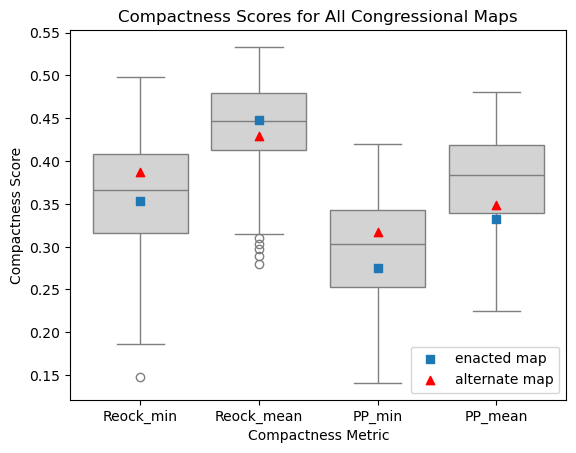

In [21]:
x = maps_df['measure']
y = maps_df['enacted']
b = maps_df['alternate']

X=compactness_df['Metric']
Y=compactness_df['compactness_score']


# plt.scatter(X, Y, alpha=.1, color='lightgray', zorder=1, label='simulated')

# compactness_analysis_df.boxplot(column=['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean'], rot=30, zorder=1, positions=range(4))
sns.boxplot(x=X, y=Y,color='lightgray', zorder=1)
plt.scatter(x=x, y=y,marker=',', label='enacted map', zorder=2)
plt.scatter(x=x, y=b, marker='^', color='red',label='alternate map', zorder=3)
plt.xlabel('Compactness Metric')
plt.ylabel('Compactness Score')
plt.title('Compactness Scores for All Congressional Maps')
plt.legend(loc='lower right')
plt.savefig('./images_for_paper/compactness_scores.png')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()
# maps_df.plot.scatter(column=['Reock_min', 'Reock_mean', 'PP_mean', 'PP_min'], zorder=2)

Regarding above boxplots, the enacted map is at or below the median for all metrics. The least compact alternate map district is more optimally compact than the least compact enacted district. Additionally, the least compact alternate district is above the median for both metrics. 

In [22]:
# Juxtaposed boxplot and scatterplot with Reock minimum only 
# reock_min=maps_df.loc[maps_df['measure']=='Reock_min'][['enacted', 'alternate']]
# plt.boxplot(x=compactness_analysis_df['Reock_min'], zorder=1)
# plt.scatter(x=[1,1], y=reock_min, zorder=2)
# plt.show()


## Computing percentiles of enacted and alternate maps

In [23]:
reock_min_summary=list(compactness_analysis_df['Reock_min'].describe())[1:]
reock_min_summary.pop(1)
reock_mean_summary=list(compactness_analysis_df['Reock_mean'].describe())[1:]
reock_mean_summary.pop(1)
PP_min_summary=list(compactness_analysis_df['PP_min'].describe())[1:]
PP_min_summary.pop(1)
PP_mean_summary=list(compactness_analysis_df['PP_mean'].describe())[1:]
PP_mean_summary.pop(1)

0.053137176692595225

In [24]:
summary_dict= { 'Statistic': ['Mean', 'Minimum', 'Quartile 1', 'Median', 'Quartile 3', 'Maximum']
               ,'Reock Min': reock_min_summary
               ,'Reock Mean': reock_mean_summary
               ,'Polsby-Popper Min': PP_min_summary
               ,'Polsby-Popper Mean': PP_mean_summary
}

compactness_stats=pd.DataFrame(summary_dict)
compactness_stats

,Statistic,Reock Min,Reock Mean,Polsby-Popper Min,Polsby-Popper Mean
0,Mean,0.358389,0.442065,0.297835,0.377748
1,Minimum,0.147263,0.279657,0.141041,0.225026
2,Quartile 1,0.316373,0.413246,0.252500,0.338932
3,Median,0.365781,0.446453,0.303371,0.383135
4,Quartile 3,0.408728,0.479470,0.342806,0.418267
5,Maximum,0.498430,0.533403,0.419491,0.480584


In [25]:
# Exporting to excel file in case we need to convert it to a LaTeX table with a table generator
compactness_stats.to_csv('./data/compactness_stats.csv',index=False, header=True)

In [26]:
reock_min_array=compactness_analysis_df['Reock_min'].to_numpy()
reock_mean_array=compactness_analysis_df['Reock_mean'].to_numpy()
pp_min_array=compactness_analysis_df['PP_min'].to_numpy()
pp_mean_array=compactness_analysis_df['PP_mean'].to_numpy()

In [27]:
percentile_dict = { 'measure': ['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']
            , 'enacted': [percentileofscore(reock_min_array, maps_df.iloc[0]['enacted'])
                          ,percentileofscore(reock_mean_array, maps_df.iloc[1]['enacted'])
                          ,percentileofscore(pp_min_array, maps_df.iloc[2]['enacted'])
                          ,percentileofscore(pp_mean_array, maps_df.iloc[3]['enacted'])]
            , 'alternate': [percentileofscore(reock_min_array, maps_df.iloc[0]['alternate'])
                            ,percentileofscore(reock_mean_array, maps_df.iloc[1]['alternate'])
                            ,percentileofscore(pp_min_array, maps_df.iloc[2]['alternate'])
                            ,percentileofscore(pp_mean_array, maps_df.iloc[3]['alternate'])]
                }

In [28]:
percentile_df=pd.DataFrame(percentile_dict)
percentile_df

,measure,enacted,alternate
0,Reock_min,44.4,64.4
1,Reock_mean,51.2,35.2
2,PP_min,32.0,57.6
3,PP_mean,18.8,30.4


## Calculating population deviation for enacted and alternate maps

In [13]:
ideal_population=797592.25
min_district=ideal_population*.99
max_district=ideal_population*1.01
print(min_district, max_district)

789616.3275 805568.1725


In [37]:
(((enacted_map['population']-ideal_population).abs())/ideal_population)*100

0    0.001034
1    0.000407
2    0.005172
3    0.006614
Name: population, dtype: float64

In [38]:
(((alternate_map['population']-ideal_population).abs())/ideal_population)*100

0    0.007867
1    0.004545
2    0.001034
3    0.002288
Name: population, dtype: float64

In [39]:
enacted_abs_mean_dev=((((enacted_map['population']-ideal_population).abs())/ideal_population).mean())*100
alternate_abs_mean_dev= ((((alternate_map['population']-ideal_population).abs())/ideal_population).mean())*100
print('mean population deviation for enacted map is', enacted_abs_mean_dev)
print('mean population deviation for the alternate map is', alternate_abs_mean_dev)

mean population deviation for enacted map is 0.003306827517443907
mean population deviation for the alternate map is 0.003933714250608628


## Absolute mean deviation

Compute deviation percentage variance by $ \frac{| dist_{pop} - ideal|}{ideal}*100$ 

The absolute mean deviation is the average all districts' deviation percentage variance.

In [24]:
simulated_map_pops=all_maps_sans_duplicates[['seed', 'dist1_pop', 'dist2_pop', 'dist3_pop', 'dist4_pop']].copy()
simulated_map_pops.head()

,seed,dist1_pop,dist2_pop,dist3_pop,dist4_pop
0,000,790938,795610,799037,804784
1,001,800842,802747,791513,795267
2,003,792024,802422,791071,804852
3,004,795671,795948,800138,798612
4,005,797813,795792,797831,798933


In [25]:
# deviation percent variance
simulated_map_pops['dist1_dpv']=(((simulated_map_pops['dist1_pop']-ideal_population).abs())/ideal_population)*100
simulated_map_pops['dist2_dpv']=(((simulated_map_pops['dist2_pop']-ideal_population).abs())/ideal_population)*100
simulated_map_pops['dist3_dpv']=(((simulated_map_pops['dist3_pop']-ideal_population).abs())/ideal_population)*100
simulated_map_pops['dist4_dpv']=(((simulated_map_pops['dist4_pop']-ideal_population).abs())/ideal_population)*100
simulated_map_pops.head()

,seed,dist1_pop,dist2_pop,dist3_pop,dist4_pop,dist1_dpv,dist2_dpv,dist3_dpv,dist4_dpv
0,000,790938,795610,799037,804784,0.834292,0.248529,0.181139,0.901683
1,001,800842,802747,791513,795267,0.407445,0.646289,0.762200,0.291534
2,003,792024,802422,791071,804852,0.698132,0.605541,0.817617,0.910208
3,004,795671,795948,800138,798612,0.240881,0.206152,0.319179,0.127854
4,005,797813,795792,797831,798933,0.027677,0.225711,0.029934,0.168100


In [30]:
simulated_map_pops['abs_mean_dev']=simulated_map_pops.iloc[:, 5:9].mean(axis=1)
simulated_map_pops.head()

,seed,dist1_pop,dist2_pop,dist3_pop,dist4_pop,dist1_dpv,dist2_dpv,dist3_dpv,dist4_dpv,abs_mean_dev
0,000,790938,795610,799037,804784,0.834292,0.248529,0.181139,0.901683,0.541411
1,001,800842,802747,791513,795267,0.407445,0.646289,0.762200,0.291534,0.526867
2,003,792024,802422,791071,804852,0.698132,0.605541,0.817617,0.910208,0.757875
3,004,795671,795948,800138,798612,0.240881,0.206152,0.319179,0.127854,0.223516
4,005,797813,795792,797831,798933,0.027677,0.225711,0.029934,0.168100,0.112855


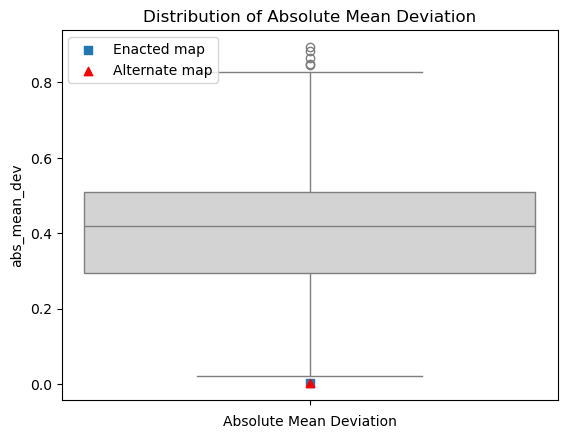

In [43]:
# pops = map_pops['measure']
# enacted_pops = map_pops['enacted']
# alt_pops = map_pops['alternate']

simulated_abs_mean_dev =  simulated_map_pops['abs_mean_dev']

sns.boxplot(simulated_abs_mean_dev, color='lightgray',  zorder=1)


plt.scatter(x=[0], y=enacted_abs_mean_dev, marker=',', label='Enacted map', zorder=2)
plt.scatter(x=[0], y=alternate_abs_mean_dev, marker='^', color='red', label='Alternate map', zorder=3)
plt.xlabel('Absolute Mean Deviation')
plt.title('Distribution of Absolute Mean Deviation')
plt.legend(loc='upper left')
plt.savefig('./images_for_paper/absolute_mean_dev.png')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()

### Removing simulated maps that don't fall in 1% deviation (relevant for 7/31/25 to prep Iowa_districtgenerator to rerun seeds)

In [33]:
# Find maps that satisfy population requirements
# maps_within_pop_range=compactness_analysis_df.loc[(compactness_analysis_df['min_pop']>min_district) & (compactness_analysis_df['max_pop']<max_district)]['seed'].tolist()

In [34]:
# Turn the ints into strings from maps_within_pop_range
# maps_within_pop_range_list=[]
# for number in maps_within_pop_range:
#     maps_within_pop_range_list.append(str(number).rjust(3, '0'))

# seeds_to_rerun_ints = [seed for seed in seeds if seed not in maps_within_pop_range]
# # seeds_to_rerun_ints

# Create a list all seed numbers as strings
# seeds=list(range(260))
# seeds_list = []
# for seed_number in seeds:
#     seeds_list.append(str(seed_number).rjust(3, '0'))

# Generate a list of seeds to rerun for population requirements
# seeds_to_rerun = [seed for seed in seeds_list if seed not in maps_within_pop_range_list]
# # =seeds_list.remove(maps_within_pop_range_list)
# len(seeds_to_rerun)

In [35]:
# Find and remove all csv and image files for district maps that don't satisfy population requirements
# file_name_district= './allocation_by_district/seed_{}_by_district.csv'
# for iter_number in seeds_to_rerun:
# #    iter_number=str(i).rjust(3,'0')
#     os.remove(file_name_district.format(iter_number))
# #    df_list.append(pd.read_csv(file_name.format(iter_number)))

# file_name_county = './allocation_by_county/seed_{}_by_county.csv'
# for iter_number in seeds_to_rerun:
#     os.remove(file_name_county.format(iter_number))

# file_name_distmap = './district_maps/seed_{}_district_map.png'
# for iter_number in seeds_to_rerun:
#     os.remove(file_name_distmap.format(iter_number))

## Graphing populations for all maps

In [36]:
map_pop_dict = { 'measure': ['min_pop', 'max_pop']
            , 'enacted': [enacted_map['population'].min(),enacted_map['population'].max()]
            , 'alternate': [alternate_map['population'].min(),alternate_map['population'].max()]}
map_pops=pd.DataFrame(map_pop_dict)
map_pops

,measure,enacted,alternate
0,min_pop,797551,797556
1,max_pop,797645,797655


In [37]:
#unstack compactness_analysis_df to prep for district population graphics
dist_pop_df=compactness_analysis_df[['min_pop', 'max_pop']].unstack().reset_index(drop=False)
dist_pop_df=dist_pop_df.drop(columns=['level_1'])
dist_pop_df=dist_pop_df.rename(columns={"level_0": "min_max", 0:"population"})
dist_pop_df

,min_max,population
0,min_pop,790938
1,min_pop,791513
2,min_pop,791071
3,min_pop,795671
4,min_pop,795792
...,...,...
495,max_pop,803932
496,max_pop,800869
497,max_pop,801541
498,max_pop,803907


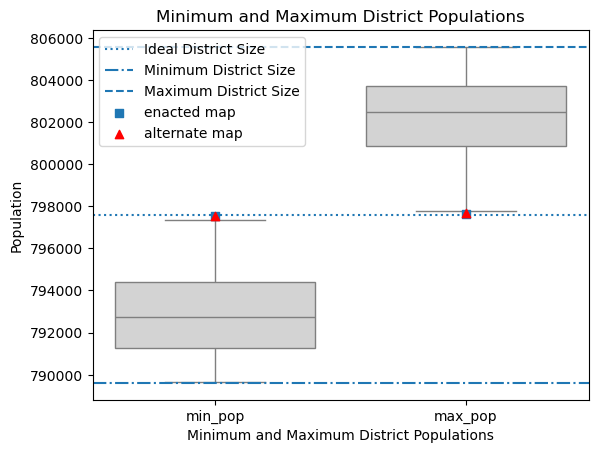

In [38]:
pops = map_pops['measure']
enacted_pops = map_pops['enacted']
alt_pops = map_pops['alternate']
min_district=ideal_population*.99
max_district=ideal_population*1.01

simulated_pop_metric =dist_pop_df['min_max']
simulated_dist_populations = dist_pop_df['population']

sns.boxplot(x=simulated_pop_metric, y=simulated_dist_populations,color='lightgray',  zorder=1)

# compactness_analysis_df.boxplot(column=['min_pop', 'max_pop'], rot=30, zorder=1, positions=range(2))
plt.axhline(ideal_population, linestyle='dotted', label='Ideal District Size')
plt.axhline(y=min_district, label='Minimum District Size', linestyle='dashdot')
plt.axhline(max_district, label='Maximum District Size', linestyle='--')
plt.scatter(x=pops, y=enacted_pops, marker=',', label='enacted map', zorder=2)
plt.scatter(x=pops, y=alt_pops, marker='^', color='red', label='alternate map', zorder=3)
plt.xlabel('Minimum and Maximum District Populations')
plt.ylabel('Population')
plt.title('Minimum and Maximum District Populations')
plt.legend(loc='upper left')
plt.savefig('./images_for_paper/min_max_dist_pops.png')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()

## Finding alternate maps

In [ ]:
all_maps_sans_duplicates.loc[all_maps_sans_duplicates['seed']=='208']

In [ ]:
seed208_pops = [798882, 801541, 792295, 797651]
pop_dev_208 = []
for pop in seed208_pops:
    deviance=(abs((pop - ideal_population))/ideal_population)*100
    pop_dev_208.append(deviance)
sum(pop_dev_208)/len(pop_dev_208)


In [ ]:
all_maps_sans_duplicates.loc[all_maps_sans_duplicates['seed']=='052']

In [ ]:
seed52_pops = [799525, 796396, 795321, 799127]
pop_dev_52 = []
for pop in seed52_pops:
    deviance=(abs((pop - ideal_population))/ideal_population)*100
    pop_dev_52.append(deviance)
sum(pop_dev_52)/len(pop_dev_52)


In [ ]:
ideal_population*.03

In [ ]:
# Find simulated maps with more optimally compact districts with the smallest population deviation
# Criteria: compactness metrics above 50th percentile, min district population above 75th percentile, max district population below 25th percentile

map_search_df=compactness_analysis_df.loc[(compactness_analysis_df['Reock_min']>0.368119 )
                            & (compactness_analysis_df['Reock_mean']>0.445834)
                            & (compactness_analysis_df['PP_min']>0.300280)
                            & (compactness_analysis_df['PP_mean']>0.378956)
                            & (compactness_analysis_df['min_pop']>794443)
                            & (compactness_analysis_df['max_pop']<800615)
                            ]['seed']
map_search_seeds = list(map(int, map_search_df.tolist()))
print(map_search_seeds)

In [ ]:
map_search_df

In [ ]:
seat_share_2024[seat_share_2024['iteration'].isin(map_search_seeds)]
#.loc[seat_share_2024['dem_seats']>0]
